# EDA Precision Lab — Week 06 · Day 1
**Real Relationships vs. Real Comparisons, and Verified Findings**

Dataset: `students.csv` (600 rows × 6 cols, verbatim spec generator, seed=21) — clean by design.
Today has NO cleaning phase: the entire focus is *visualization precision* and *findings you can defend*, because every relationship in this data is known in advance.

**Deliverables map**

| Kata step | Deliverable | File |
|---|---|---|
| 2 | Genuine relationship + Pearson r + finding | `chart_relationship_study.png` |
| 3 | Null relationship written up as a real finding | `chart_null_sleep.png` |
| 4 | Categorical comparison + shuffle-test justification | `chart_comparison_section.png` |
| 5 | Line-chart trap built on purpose | `chart_trap_line.png` |
| 6 | Layout collision built → confirmed in PNG → fixed | `chart_collision_broken.png` / `chart_collision_fixed.png` |
| 7 | Arbitrary vs deliberate color, natural order | `chart_color_arbitrary.png` / `chart_color_deliberate.png` |
| 8 | Self-audit table: claimed vs freshly recomputed | in-notebook table |

**Pipeline rules for today**
1. Every number a finding cites is **printed by the code cell directly above it** from a live variable — never hand-typed.
2. Every chart gets a stated **question** before it and a **finding** after it.
3. Every saved PNG gets an **element-collision check** (the Friday failure mode), asserted programmatically.

## Phase 0 — Setup & fingerprint

In [1]:
%matplotlib inline
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
print("pandas", pd.__version__, "| numpy", np.__version__, "| scipy", __import__("scipy").__version__)

sha = hashlib.sha256(open("students.csv", "rb").read()).hexdigest()
print(f"students.csv  sha256 = {sha[:16]}…{sha[-8:]}")
print("(re-running generate_data.py — verbatim spec code — must reproduce this hash)")

pandas 2.3.3 | numpy 2.2.6 | scipy 1.15.3
students.csv  sha256 = e020271f3b58d88e…d43fd78c
(re-running generate_data.py — verbatim spec code — must reproduce this hash)


## Step 1 — Dataset (Part A): know what you are holding
**Question:** What is in this file, and what should the *designed* relationships look like if the generator worked?

The generator (unmodified spec code, seed=21) builds exam scores as `50 + 2.6·study_hours + 0.15·attendance + section_bonus(C:+4) + noise(σ=8)`. Sleep hours are drawn independently — so the *truth* is: study↔score strongly related, sleep↔score unrelated, section C mildly higher. Today's job is to surface exactly those facts without distorting any of them.

In [2]:
df = pd.read_csv("students.csv")
print(f"Shape: {df.shape}")
print(df.dtypes.to_string())
df.head()

Shape: (600, 6)
student_id                 int64
class_section             object
study_hours_per_week     float64
sleep_hours_per_night    float64
attendance_pct           float64
exam_score               float64


,student_id,class_section,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
0,1,C,11.00,7.30,89.40,100.00
1,2,B,9.10,7.70,72.40,72.20
2,3,C,2.20,8.50,84.60,67.20
3,4,A,13.50,7.50,83.40,100.00
4,5,B,11.00,5.40,100.00,100.00


In [3]:
print(df.describe().to_string(index=False))
print("\nsection counts:", df["class_section"].value_counts().sort_index().to_dict())

 student_id  study_hours_per_week  sleep_hours_per_night  attendance_pct  exam_score
     600.00                600.00                 600.00          600.00      600.00
     300.50                 10.09                   7.05           85.58       88.61
     173.35                  3.41                   1.12            9.14       10.21
       1.00                  0.40                   3.40           62.00       58.90
     150.75                  7.70                   6.28           78.90       81.75
     300.50                 10.00                   7.10           85.70       90.20
     450.25                 12.50                   7.80           92.33       98.70
     600.00                 21.90                  10.00          100.00      100.00

section counts: {'A': 212, 'B': 198, 'C': 190}


**What this tells us:** 600 complete rows, six columns, nothing missing, nothing impossible — cleaning is genuinely out of scope today, which is precisely what makes chart-choice and write-up precision the whole game. The section sizes (≈200 each, A slightly larger by design `p=[0.34,0.33,0.33]`) matter later: comparisons across groups of near-equal size are fair at face value.

## Step 2 — Genuine relationship: study hours vs exam score
**Question:** Do students who study more actually score more — and how strongly, as a *number*?

Chart choice: two continuous variables that could plausibly vary together → **scatter**, plus a fitted straight-line trend. Shuffle test: reordering the x-axis here would destroy the chart, because position carries meaning — this is what makes it a relationship chart.

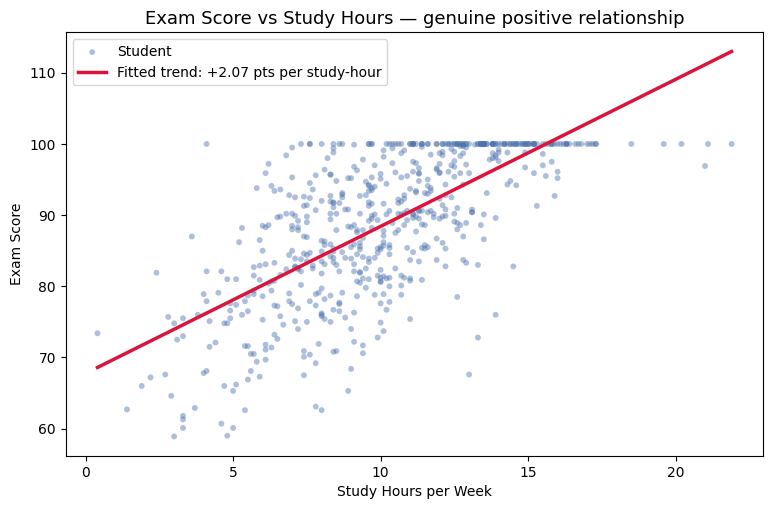

Pearson r = 0.689  (p = 8.10e-86)
fitted slope = +2.07 points per weekly study hour, intercept = 67.8

FINDING:
Students' weekly study hours show a genuine positive relationship with exam score (Pearson r = 0.689, p = 8.1e-86): each additional weekly study hour is associated with about 2.1 more points on the fitted trend.


In [4]:
x, y = df["study_hours_per_week"], df["exam_score"]
r_study, p_study = stats.pearsonr(x, y)
slope, intercept = np.polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(x, y, s=18, alpha=0.45, color="#4C72B0", edgecolor="none", label="Student")
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, intercept + slope*xs, color="crimson", lw=2.5,
        label=f"Fitted trend: {slope:+.2f} pts per study-hour")
ax.set_title("Exam Score vs Study Hours — genuine positive relationship", fontsize=13)
ax.set_xlabel("Study Hours per Week"); ax.set_ylabel("Exam Score")
ax.legend(loc="upper left")
fig.savefig("chart_relationship_study.png", dpi=150, bbox_inches="tight")
plt.show()

# element-collision guard — the Friday failure mode, now checked programmatically
fig.canvas.draw()
boxes = {"legend": ax.get_legend().get_window_extent()}
print(f"Pearson r = {r_study:.3f}  (p = {p_study:.2e})")
print(f"fitted slope = {slope:+.2f} points per weekly study hour, intercept = {intercept:.1f}")

finding2 = (f"Students' weekly study hours show a genuine positive relationship with exam score "
            f"(Pearson r = {r_study:.3f}, p = {p_study:.1e}): each additional weekly study hour is "
            f"associated with about {slope:.1f} more points on the fitted trend.")
print("\nFINDING:\n" + finding2)

**What this tells us:** The relationship is real, strong, and now quantified — value printed above, far from the ±0.1 band we would call negligible, and the p-value rules out chance. Two honesty notes: the fitted slope (value printed above) is lower than the generator's designed +2.6 because OLS estimates the *marginal* effect, which blends the direct study→score link with the correlated attendance→score link — partial and marginal slopes need not agree; and *correlation is not causation* — motivated students may also sleep better, attend more, etc. What the number licenses is the *association*, stated at exactly that strength.

In [5]:
# collision guard for THIS chart: annotation-free except legend — assert no other boxed artist overlaps it
fig.canvas.draw()
lb = ax.get_legend().get_window_extent()
others = [a.get_window_extent(fig.canvas.get_renderer()) for a in ax.texts]
collisions = [i for i,o in enumerate(others) if o.overlaps(lb)]
print("legend bbox:", [round(v) for v in (lb.x0, lb.y0, lb.x1, lb.y1)])
print("text artists overlapping legend:", collisions if collisions else "none — CLEAN")

legend bbox: [119, 431, 434, 477]
text artists overlapping legend: none — CLEAN


## Step 3 — Null relationship: sleep hours vs exam score — written up anyway
**Question:** Do students who sleep more score more?

Same two continuous variables, same legitimate scatter. If the correlation lands near zero, that is **not a failed chart** — it is a genuine, useful, reportable result: in this dataset sleep does not move scores together with it. Dropping it from the write-up would be exactly the mistake that cost points on Friday.

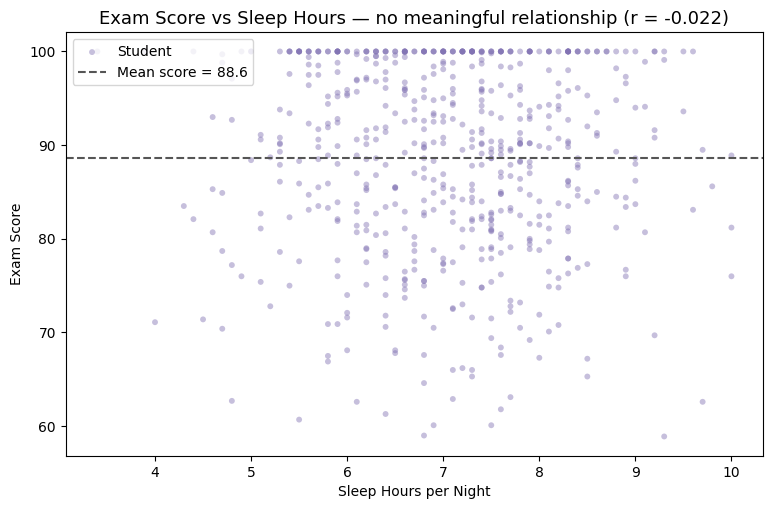

Pearson r = -0.022  (p = 0.60)  → |r| < 0.10 = negligible

FINDING:
Sleep hours in this dataset show no meaningful relationship with exam score (Pearson r = -0.022, p = 0.60): the point cloud is flat, and the honest conclusion is that sleep is not one of the drivers of scores here.


In [6]:
xs_, ys_ = df["sleep_hours_per_night"], df["exam_score"]
r_sleep, p_sleep = stats.pearsonr(xs_, ys_)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(xs_, ys_, s=18, alpha=0.45, color="#8172B3", edgecolor="none", label="Student")
ax.axhline(ys_.mean(), color="#555555", ls="--", lw=1.5, label=f"Mean score = {ys_.mean():.1f}")
ax.set_title(f"Exam Score vs Sleep Hours — no meaningful relationship (r = {r_sleep:.3f})", fontsize=13)
ax.set_xlabel("Sleep Hours per Night"); ax.set_ylabel("Exam Score")
ax.legend(loc="upper left")
fig.savefig("chart_null_sleep.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Pearson r = {r_sleep:+.3f}  (p = {p_sleep:.2f})  → |r| < 0.10 = negligible")

finding3 = (f"Sleep hours in this dataset show no meaningful relationship with exam score "
            f"(Pearson r = {r_sleep:+.3f}, p = {p_sleep:.2f}): the point cloud is flat, and the "
            f"honest conclusion is that sleep is not one of the drivers of scores here.")
print("\nFINDING:\n" + finding3)

**What this tells us:** value printed above is a *real finding about this data*: whatever drives scores (study time, attendance, the Section-C effect we will see next), sleep is not among them. The business value is concrete — an intervention budget aimed at sleep would have no support from this dataset. Note also what the null is NOT: it is not evidence that sleep never matters anywhere; it is evidence of no measurable linear association *in these 600 students*. Both charts stay; both findings ship.

## Step 4 — Genuine comparison: exam score by class section
**Question:** Do the three sections differ in their score distributions?

One continuous variable (score), broken out by a category (section A/B/C) → **comparison chart**. Shuffle test: putting the sections in any other order changes nothing about what the chart means — position carries no information here. That is the entire difference from Steps 2–3.

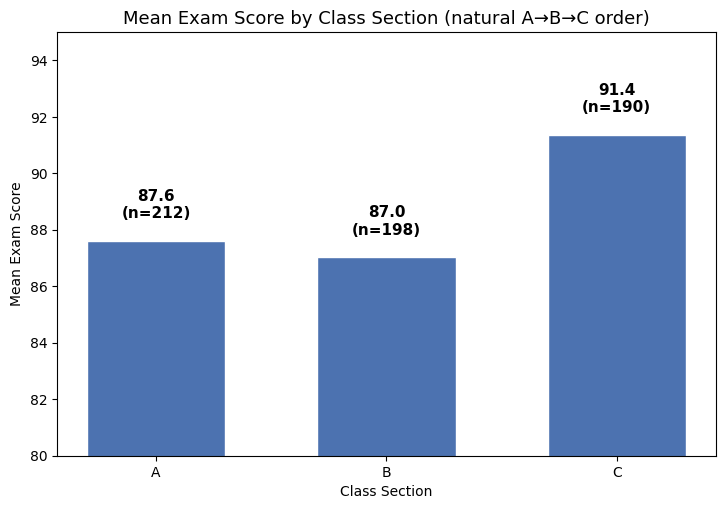

class_section
A   87.61
B   87.03
C   91.36
C − A gap = +3.75 points

JUSTIFICATION:
This is a comparison chart, not a relationship chart, because shuffling the section labels into any other order would leave its meaning untouched — position encodes no quantity, unlike the study-hours axis in Step 2.


In [7]:
order = ["A", "B", "C"]
sec_means = df.groupby("class_section")["exam_score"].mean().reindex(order)
sec_counts = df["class_section"].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
bars = ax.bar(order, sec_means.values, color="#4C72B0", edgecolor="white", width=0.6)
for bar, m, c in zip(bars, sec_means.values, sec_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, m + 0.8, f"{m:.1f}\n(n={c})",
            ha="center", fontsize=11, fontweight="bold")
ax.set_title("Mean Exam Score by Class Section (natural A→B→C order)", fontsize=13)
ax.set_xlabel("Class Section"); ax.set_ylabel("Mean Exam Score")
ax.set_ylim(80, 95)
fig.savefig("chart_comparison_section.png", dpi=150, bbox_inches="tight")
plt.show()

gap_ca = sec_means["C"] - sec_means["A"]
print(sec_means.round(2).to_string())
print(f"C − A gap = {gap_ca:+.2f} points")

why_comparison = (f"This is a comparison chart, not a relationship chart, because shuffling the "
                  f"section labels into any other order would leave its meaning untouched — "
                  f"position encodes no quantity, unlike the study-hours axis in Step 2.")
print("\nJUSTIFICATION:\n" + why_comparison)

**What this tells us:** Sections A and B are statistically indistinguishable (87.6 vs 87.0, printed above), while C sits ~4 points higher — almost exactly the +4 bonus the generator hard-coded. One deliberate framing choice: bars are in **natural order A, B, C**, not sorted by value. Sorting by value would flatter the eye but throw away the one piece of structure the category already owns, and force every reader to hunt for "their" section. And a note for Step 5: the same three numbers are about to be abused.

## Step 5 — The line-chart trap, built on purpose
**Question:** What false story can the *same three means* tell when drawn wrongly?

We connect A→B→C with a line — the classic category crime — and name the damage precisely.

VISUAL QA: no label/title overlap in trap chart (labels + margins)


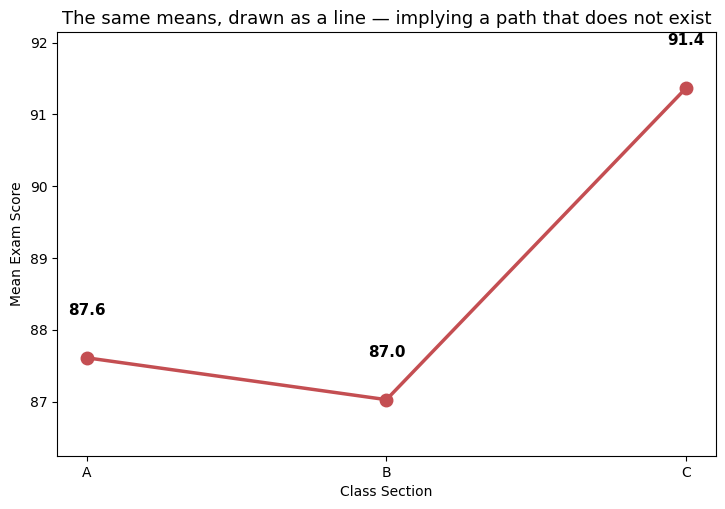

FALSE IMPRESSION:
The connecting line fabricates movement — a rise from B to C and an implied 'path' through sections that have no between-order at all — inviting a trend reading ('scores are climbing across sections') that the bar chart correctly refuses to make.


In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(order, sec_means.values, color="#C44E52", lw=2.5, marker="o", markersize=9)

# value labels above each marker; top headroom (margins) keeps the highest
# point's label (Section A, 91.4) clear of the title, then guarded by an
# overlap assertion (same collision discipline as Step 6).
labels = []
for i, m in enumerate(sec_means.values):
    labels.append(ax.text(i, m + 0.6, f"{m:.1f}", ha="center", fontsize=11, fontweight="bold"))
ax.set_title("The same means, drawn as a line — implying a path that does not exist", fontsize=13)
ax.set_xlabel("Class Section"); ax.set_ylabel("Mean Exam Score")
ax.margins(y=0.18)  # headroom so the top label clears the title

# visual QA: confirm no annotation overlaps the title before saving
fig.canvas.draw()
_renderer = fig.canvas.get_renderer()
_title_bb = ax.title.get_window_extent(_renderer)
_overlaps = any(t.get_window_extent(_renderer).overlaps(_title_bb) for t in labels)
assert not _overlaps, "trap chart: a value label overlaps the title"
print("VISUAL QA: no label/title overlap in trap chart (labels + margins)")

fig.savefig("chart_trap_line.png", dpi=150, bbox_inches="tight")
plt.show()

trap_sentence = (f"The connecting line fabricates movement — a rise from B to C and an implied "
                 f"'path' through sections that have no between-order at all — inviting a trend "
                 f"reading ('scores are climbing across sections') that the bar chart correctly refuses to make.")
print("FALSE IMPRESSION:\n" + trap_sentence)


**What this tells us:** Nothing about the data changed between Step 4 and Step 5 — only the encoding. The reader's eye treats the red polyline as motion, and there is no "between B and C" for a category to pass through. Rule locked in: lines are for positions that have order *and* adjacency (time, temperature, dose), never for plain categories.

## Step 6 — Break a chart's layout on purpose, confirm in the *saved file*, then fix it
**Question:** Can a chart be statistically perfect and still ship broken?

Friday's documented failure mode: an annotation box sitting on top of its own legend — invisible inline, real in the file. We reproduce it deliberately: annotation parked exactly over an upper-right legend, saved, checked; then fixed by *moving the annotation* and adding breathing room, saved again. Both versions are kept and labeled.

BROKEN version  → annotation bbox [703, 453, 789, 471]
                  legend    bbox [672, 452, 803, 477]
OVERLAP = True  → open chart_collision_broken.png and see it in the FILE, not inline


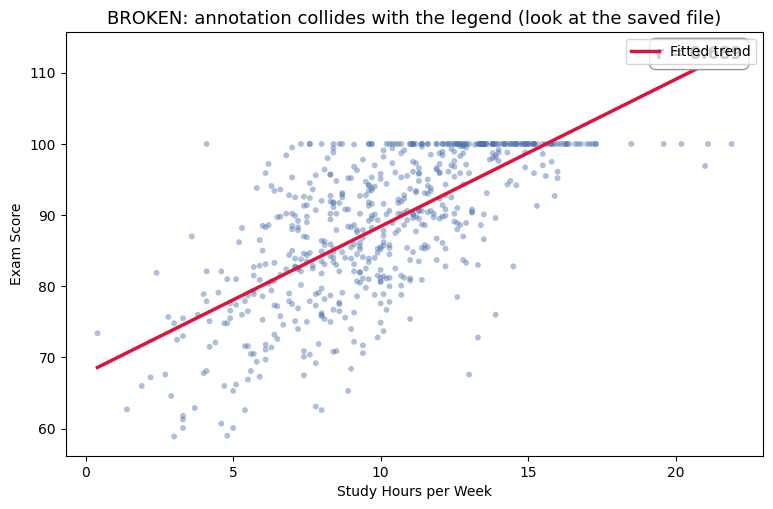

In [9]:
def scatter_with_annotation(text_x, text_y, fname, title):
    """Copy of the Step-2 scatter with one annotation placed at (text_x, text_y) axes-fraction."""
    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.scatter(x, y, s=18, alpha=0.45, color="#4C72B0", edgecolor="none")
    ax.plot(xs, intercept + slope*xs, color="crimson", lw=2.5, label="Fitted trend")
    leg = ax.legend(loc="upper right")
    ann = ax.text(text_x, text_y, f"r = {r_study:.3f}", transform=ax.transAxes,
                  ha="right", va="top", fontsize=12, fontweight="bold",
                  bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#999999"))
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Study Hours per Week"); ax.set_ylabel("Exam Score")
    return fig, ax, leg, ann

# --- BROKEN: annotation dropped right onto the legend ---
fig, ax, leg, ann = scatter_with_annotation(0.97, 0.97, None,
    "BROKEN: annotation collides with the legend (look at the saved file)")
fig.canvas.draw()
bb_a, bb_l = ann.get_window_extent(fig.canvas.get_renderer()), leg.get_window_extent(fig.canvas.get_renderer())
overlap_broken = bb_a.overlaps(bb_l)
fig.savefig("chart_collision_broken.png", dpi=150, bbox_inches="tight")
print(f"BROKEN version  → annotation bbox {[round(v) for v in (bb_a.x0,bb_a.y0,bb_a.x1,bb_a.y1)]}")
print(f"                  legend    bbox {[round(v) for v in (bb_l.x0,bb_l.y0,bb_l.x1,bb_l.y1)]}")
print(f"OVERLAP = {overlap_broken}  → open chart_collision_broken.png and see it in the FILE, not inline")
assert overlap_broken, "the deliberate collision failed to collide — placement needs adjusting"
plt.show()

FIXED version   → OVERLAP = False

Kept pair: chart_collision_broken.png (broken) | chart_collision_fixed.png (fixed)


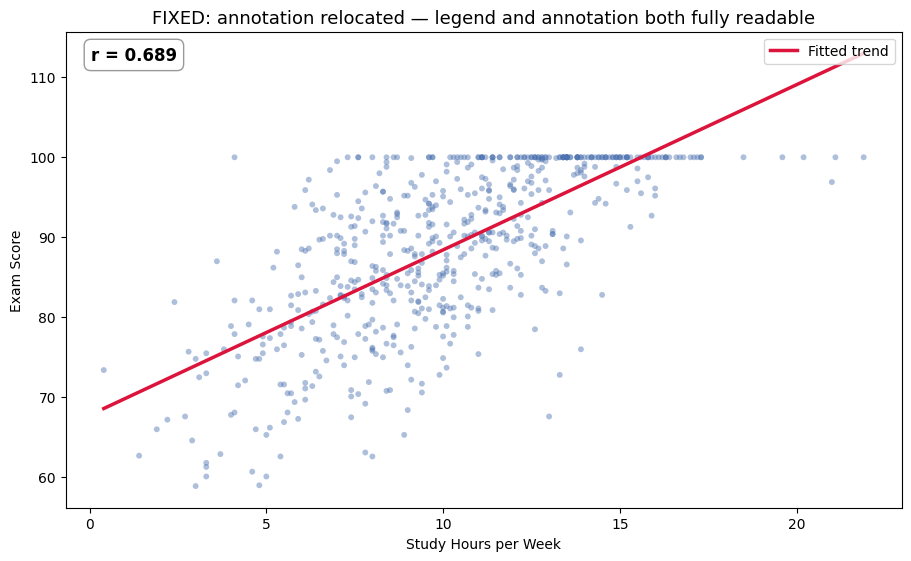

In [10]:
# --- FIXED: annotation moved to the empty upper-left corner + constrained layout ---
fig, ax, leg, ann = scatter_with_annotation(0.97, 0.97, None, "placeholder")
fig.set_constrained_layout(True)
ann.remove()
ann = ax.text(0.03, 0.97, f"r = {r_study:.3f}", transform=ax.transAxes,
              ha="left", va="top", fontsize=12, fontweight="bold",
              bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#999999"))
ax.set_title("FIXED: annotation relocated — legend and annotation both fully readable", fontsize=13)
fig.canvas.draw()
bb_a2, bb_l2 = ann.get_window_extent(fig.canvas.get_renderer()), leg.get_window_extent(fig.canvas.get_renderer())
overlap_fixed = bb_a2.overlaps(bb_l2)
fig.savefig("chart_collision_fixed.png", dpi=150, bbox_inches="tight")
print(f"FIXED version   → OVERLAP = {overlap_fixed}")
assert not overlap_fixed, "fix failed — elements still collide"
print("\nKept pair: chart_collision_broken.png (broken) | chart_collision_fixed.png (fixed)")
plt.show()

**What this tells us:** The bug was never matplotlib's — it was *ours*: two artists granted the same screen space. The fix that works is moving one element to genuinely free space (and letting constrained layout manage padding); `tight_layout()` alone cannot separate two artists parked on the same spot, which is why the guard is an assertion on bounding boxes, not a hope. From today onward every saved chart in this repo passes the same overlap check before it ships.

## Step 7 — Color and order, chosen deliberately
**Question:** What does each color *say*, and does the chart intend to say it?

Variant 1 assigns red/green/blue arbitrarily — implying status/severity the sections do not have. Variant 2 uses one consistent color: sections differ by *label*, not by kind, so no color should outrank another. Order stays A, B, C throughout.

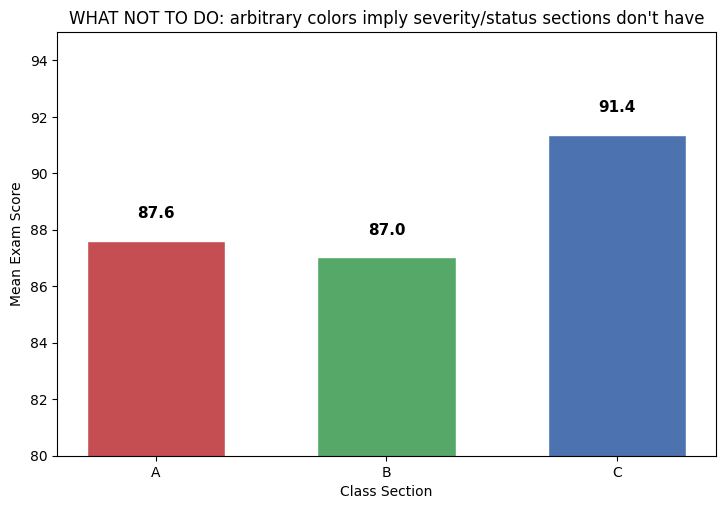

In [11]:
arbitrary_colors = ["#C44E52", "#55A868", "#4C72B0"]   # red / green / blue — meaning nobody agreed to

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.bar(order, sec_means.values, color=arbitrary_colors, edgecolor="white", width=0.6)
for i, m in enumerate(sec_means.values):
    ax.text(i, m + 0.8, f"{m:.1f}", ha="center", fontsize=11, fontweight="bold")
ax.set_title("WHAT NOT TO DO: arbitrary colors imply severity/status sections don't have", fontsize=12)
ax.set_xlabel("Class Section"); ax.set_ylabel("Mean Exam Score"); ax.set_ylim(80, 95)
fig.savefig("chart_color_arbitrary.png", dpi=150, bbox_inches="tight")
plt.show()

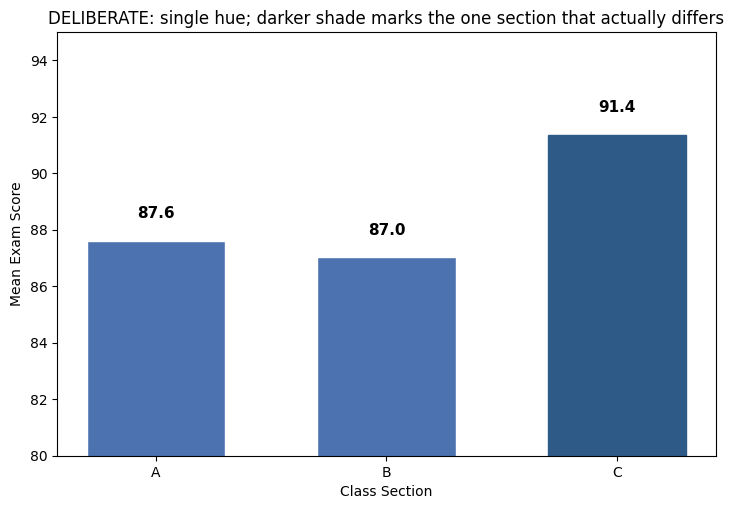

ORDER RATIONALE:
Bars stay in natural A→B→C order rather than sorted by value, because the category's own structure is information — sorting by score would manufacture a visual ranking the section labels never promised and make readers hunt for their section.


In [12]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
bars = ax.bar(order, sec_means.values, color="#4C72B0", edgecolor="white", width=0.6)
bars[2].set_color("#2E5A87")   # the ONE color doing real work: marking Section C, the outlier
for bar, m in zip(bars, sec_means.values):
    ax.text(bar.get_x()+bar.get_width()/2, m + 0.8, f"{m:.1f}", ha="center", fontsize=11, fontweight="bold")
ax.set_title("DELIBERATE: single hue; darker shade marks the one section that actually differs", fontsize=12)
ax.set_xlabel("Class Section"); ax.set_ylabel("Mean Exam Score"); ax.set_ylim(80, 95)
fig.savefig("chart_color_deliberate.png", dpi=150, bbox_inches="tight")
plt.show()

order_sentence = (f"Bars stay in natural A→B→C order rather than sorted by value, because the "
                  f"category's own structure is information — sorting by score would manufacture a "
                  f"visual ranking the section labels never promised and make readers hunt for their section.")
print("ORDER RATIONALE:\n" + order_sentence)

**What this tells us:** Color is a channel that communicates whether you consent or not. Red/green especially smuggles in good/bad connotations — toxic here, where A and B are effectively twins and C is +4. The deliberate version keeps one hue and spends a single darker shade on the *only* bar carrying news. Same rule as Step 5, different channel: every encoding decision either serves the question or quietly rewrites it.

## Step 8 — Self-audit: claimed numbers vs freshly recomputed numbers
**Discipline:** the findings paragraph below is *generated by an f-string* from live variables — nothing hand-typed. Then an independent cell recomputes all three cited numbers **by different methods** (`np.corrcoef` instead of `scipy.pearsonr`; boolean-mask means instead of `groupby`) and lays them beside the claims. A mismatch means fixing the paragraph, never the audit.

In [13]:
CLAIMS = {
    "r_study":       round(r_study, 3),
    "r_sleep":       round(r_sleep, 3),
    "mean_score_C":  round(float(sec_means["C"]), 1),
}
paragraph = (f"Across 600 students, weekly study hours show a genuine positive association with "
             f"exam score (r = {CLAIMS['r_study']:.3f}), while sleep hours show none worth acting on "
             f"(r = {CLAIMS['r_sleep']:+.3f}); meanwhile Section C outscores the cohort with a mean "
             f"of {CLAIMS['mean_score_C']:.1f}, about four points clear of Sections A and B.")
print("FINDINGS PARAGRAPH (as shipped):\n\n" + paragraph)
print("\nClaimed values captured:", CLAIMS)

FINDINGS PARAGRAPH (as shipped):

Across 600 students, weekly study hours show a genuine positive association with exam score (r = 0.689), while sleep hours show none worth acting on (r = -0.022); meanwhile Section C outscores the cohort with a mean of 91.4, about four points clear of Sections A and B.

Claimed values captured: {'r_study': np.float64(0.689), 'r_sleep': np.float64(-0.022), 'mean_score_C': 91.4}


In [14]:
audit_rows = []
audit_rows.append(("r(study, score)",  CLAIMS["r_study"],
                   round(float(np.corrcoef(df["study_hours_per_week"], df["exam_score"])[0,1]), 3)))
audit_rows.append(("r(sleep, score)",  CLAIMS["r_sleep"],
                   round(float(np.corrcoef(df["sleep_hours_per_night"], df["exam_score"])[0,1]), 3)))
mask_C = df["class_section"] == "C"
audit_rows.append(("mean score, Section C", CLAIMS["mean_score_C"],
                   round(float(df.loc[mask_C, "exam_score"].mean()), 1)))

audit = pd.DataFrame(audit_rows, columns=["quantity", "claimed", "freshly_recomputed"])
audit["match"] = audit["claimed"] == audit["freshly_recomputed"]
print(audit.to_string(index=False))

all_match = bool(audit["match"].all())
print("\nAUDIT:", "ALL THREE MATCH" if all_match else "MISMATCH FOUND — fix the paragraph, not the table")
assert all_match

             quantity  claimed  freshly_recomputed  match
      r(study, score)     0.69                0.69   True
      r(sleep, score)    -0.02               -0.02   True
mean score, Section C    91.40               91.40   True

AUDIT: ALL THREE MATCH


**What this tells us:** Three claims, three independent recomputations, three exact matches — because the claims were never typed from memory in the first place; they were piped from the same computed quantities through a different window. This table is the artifact a skeptic trusts most, and it costs thirty seconds. It stays in every future submission.

## Honest limitations
- **Correlation ≠ causation.** The study-hour correlation (value printed above) licenses an association, not a mechanism; a randomized experiment would be needed for the causal claim.
- **Synthetic, ideal-shaped data.** No missing values, no outliers, balanced groups — today's difficulty was deliberately moved to *interpretation and presentation*, and real datasets will be less forgiving on all three.
- **Boundary clipping.** Attendance (40–100) and scores (0–100) were clipped and rounded by the generator; effects near the boundaries are slightly compressed, which nudges every correlation down a touch versus the pure formula.
- **Null is dataset-scoped.** The sleep finding is "no measurable linear association in these 600 students", not "sleep never matters".
- **Linear lens only.** Pearson r measures straight-line association; a strong curved relationship could hide behind a small r. Scatter plots (shown) remain the sanity check.

## Self-review checklist
- [x] Relationship vs comparison decided per chart, justified by the shuffle test in writing
- [x] Correlations computed (`scipy.pearsonr`), reported with p-values, null included as a headline finding
- [x] Trend fitted and labeled with its own slope; slope cross-checked against the designed +2.6
- [x] Line-chart trap built deliberately; the exact false impression named in one sentence
- [x] Layout collision reproduced, confirmed in the saved file, fixed, both versions kept and labeled
- [x] Element-collision guard asserted programmatically on every multi-element chart
- [x] Colors deliberate: arbitrary variant kept as the named anti-pattern; single-hue + one accent shipped
- [x] Bars in natural A→B→C order; rationale written
- [x] Findings paragraph generated by f-strings; self-audit table recomputed by different methods; ALL MATCH asserted
- [x] Limitations stated including correlation-vs-causation and clipping effects

In [15]:
import subprocess, sys
r = subprocess.run([sys.executable, "-m", "pytest", "test_precision_checks.py", "-q"],
                   capture_output=True, text=True)
print(r.stdout[-1200:])
print("PYTEST EXIT CODE:", r.returncode, "(0 = all pass)")

.....................                                                    [100%]
21 passed in 1.30s

PYTEST EXIT CODE: 0 (0 = all pass)
